<a href="https://colab.research.google.com/github/Guhman97/PythonProjectNVB-MH/blob/main/Capstone_Matthew_Hennessy0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
MY_DATASET    = "nvb_college_stem_outcomes.csv"
MY_QUESTION   = "\n 1. Do students with internships have higher GPAs and better employment outcomes? \n 2. Which major has the highest on-time graduation rate? \n 3. How does GPA vary across year groups (Freshman to Senior)?"
MY_DOMAIN     = "College stem outcomes"

print(f"Dataset:  {MY_DATASET}")
print(f"Domain:   {MY_DOMAIN}")
print(f"Questions: {MY_QUESTION}")

Dataset:  nvb_college_stem_outcomes.csv
Domain:   College stem outcomes
Question: 
 1. Do students with internships have higher GPAs and better employment outcomes? 
 2. Which major has the highest on-time graduation rate? 
 3. How does GPA vary across year groups (Freshman to Senior)?


In [ ]:
# Method 3 — Direct URL (replace YOUR_FILE_ID with the ID from Classroom)
import pandas as pd
import matplotlib.pyplot as plt
url = 'https://drive.google.com/uc?id=15NZhY30mK1ysQhTWatWv87oahSfOtq9y'
df = pd.read_csv(url)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 300 rows, 12 columns


In [ ]:
print(f"Shape: {df.shape}")
print()
print("Column types:")
print(df.dtypes)
print()
print("First 10 rows:")
print(df.head(10))
print()
print("Basic statistics:")
print(df.describe().round(2))

Shape: (300, 12)

Column types:
student_id               object
university               object
major                    object
year                     object
credits_completed       float64
cumulative_gpa          float64
internship_completed      int64
research_experience       int64
clubs_count               int64
scholarship               int64
employment_status        object
graduated_on_time       float64
dtype: object

First 5 rows:
  student_id                  university                   major       year  \
0       C001  Tennessee State University    Chemical Engineering     Senior   
1       C002             Spelman College  Electrical Engineering     Junior   
2       C003             Spelman College   Aerospace Engineering     Senior   
3       C004            Prairie View A&M   Aerospace Engineering   Freshman   
4       C005               Virginia Tech    Chemical Engineering  Sophomore   
5       C006            Prairie View A&M  Biomedical Engineering     Senior   
6 

In [17]:
# Do students with internships have higher GPAs and better employment outcomes?:
print("Missing values per column:")
print(df.isnull().sum())
print(f"Total missing: {df.isnull().sum().sum()}")
print()
# Which major has the highest on-time graduation rate?:
print("Print total of graduates:")
print(df.graduated_on_time.sum())
print()
# How does GPA vary across year groups:
print("Print average GPA:")
print(f"{(df.cumulative_gpa.sum())/len(df.cumulative_gpa):.2f}")
print()

Missing values per column:
student_id                0
university                0
major                     0
year                      0
credits_completed         4
cumulative_gpa            6
internship_completed      0
research_experience       0
clubs_count               0
scholarship               0
employment_status         6
graduated_on_time       212
dtype: int64
Total missing: 228

Print total of graduates:
80.0

Print average GPA:
2.95



In [26]:
#\n 1. Do students with internships have higher GPAs and better employment outcomes?
#\n 2. Which major has the highest on-time graduation rate?
#\n 3. How does GPA vary across year groups (Freshman to Senior)?"
df.groupby('employment_status')['internship_completed'].value_counts().unstack(fill_value=0) #searched up

# Groupby — multiple aggregations
display(df.groupby('employment_status').agg(avg_val  = ('internship_completed', 'mean'),
    count    = ('internship_completed', 'count'),
))

# Filter — keep rows matching a condition
print("students who completed internship")
display(df[df['internship_completed'] == 1])
print("students who completed internship")
display(df[df['internship_completed'] == 0])
print("students who did both ")
display(df[(df['internship_completed'] == 1) & (df['employment_status'] == 1)])

,avg_val,count
employment_status,,
Employed,0.615385,65
Grad School,0.812500,16
Not applicable,0.315534,206
Not seeking,0.400000,5
Searching,1.000000,2


students who completed internship


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time
0,C001,Tennessee State University,Chemical Engineering,Senior,117.0,3.65,1,0,4,0,Employed,1.0
1,C002,Spelman College,Electrical Engineering,Junior,88.0,2.88,1,0,3,0,Not applicable,NaN
2,C003,Spelman College,Aerospace Engineering,Senior,129.0,3.32,1,1,3,0,Employed,1.0
5,C006,Prairie View A&M,Biomedical Engineering,Senior,130.0,3.41,1,0,3,0,Grad School,1.0
10,C011,Prairie View A&M,Electrical Engineering,Senior,103.0,2.28,1,0,3,0,Employed,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
287,C288,Prairie View A&M,Data Science,Senior,117.0,2.73,1,1,3,0,Searching,1.0
288,C289,Prairie View A&M,Chemical Engineering,Senior,125.0,3.30,1,1,3,0,Employed,1.0
291,C292,Spelman College,Civil Engineering,Sophomore,54.0,2.54,1,0,3,0,Not applicable,NaN
296,C297,Prairie View A&M,Electrical Engineering,Senior,110.0,3.27,1,1,3,0,Employed,1.0


students who completed internship


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time
3,C004,Prairie View A&M,Aerospace Engineering,Freshman,40.0,3.00,0,0,4,0,Not applicable,NaN
4,C005,Virginia Tech,Chemical Engineering,Sophomore,73.0,2.88,0,0,4,0,Not applicable,NaN
6,C007,North Carolina A&T,Mechanical Engineering,Junior,83.0,3.23,0,0,3,0,NaN,NaN
7,C008,Prairie View A&M,Data Science,Senior,129.0,2.66,0,0,1,0,Employed,0.0
8,C009,Prairie View A&M,Aerospace Engineering,Junior,88.0,3.47,0,0,3,0,Not applicable,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
293,C294,Morgan State University,Mechanical Engineering,Senior,113.0,3.10,0,0,3,0,Employed,1.0
294,C295,Morgan State University,Mechanical Engineering,Sophomore,60.0,2.46,0,0,1,0,Not applicable,NaN
295,C296,Spelman College,Biomedical Engineering,Junior,97.0,3.18,0,1,2,0,Not applicable,NaN
298,C299,North Carolina A&T,Civil Engineering,Freshman,39.0,2.94,0,0,1,0,Not applicable,NaN


students who did both 


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time


In [27]:

df.groupby('employment_status')['internship_completed'].mean().sort_values(ascending=False)

# Finding 1: Everyone who did and internship is geeking for a job, but only about half of them are employed

,internship_completed
employment_status,
Searching,1.000000
Grad School,0.812500
Employed,0.615385
Not seeking,0.400000
Not applicable,0.315534


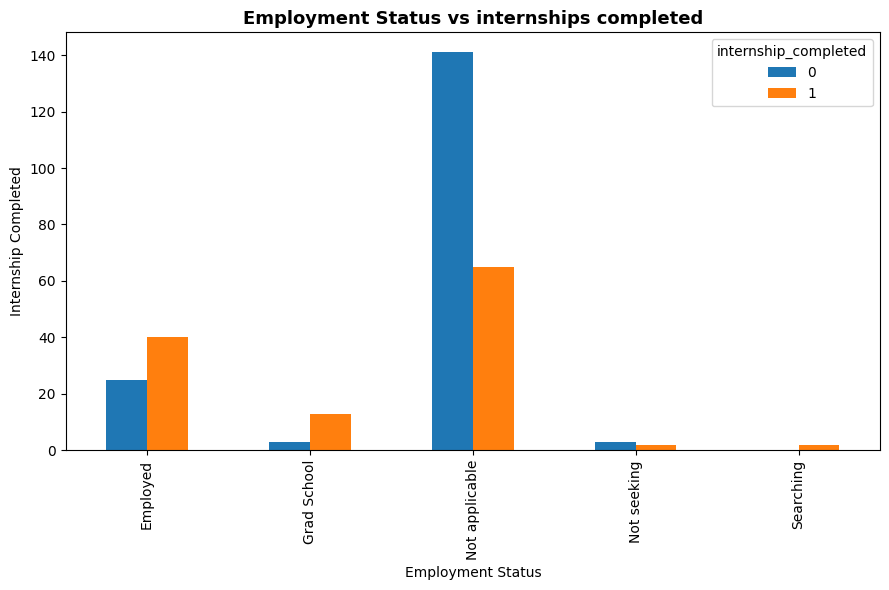

Finding: _______________________________________________


<Figure size 640x480 with 0 Axes>

In [40]:
#plt.figure(figsize=(9, 6))
colors_pass = ["#2ecc71" if p >= 1 else "#e74c3c" for p in df["internship_completed"]]

plot_data = df.groupby(['employment_status', 'internship_completed']).size().unstack(fill_value=0)
ax = plot_data.plot(kind='bar', figsize=(9, 6))
plt.title("Employment Status vs internships completed", fontsize=13, fontweight="bold")
plt.xlabel("Employment Status")
plt.ylabel("Internship Completed")
plt.tight_layout()
plt.show()
print("Finding: _______________________________________________")
plt.tight_layout()
plt.show()

In [ ]:
print("""
SUMMARY — [College stem outcomes] Exploration
==========================================
Question: [What did you set out to find?]
"\n 1. Do students with internships have higher GPAs and better employment outcomes? \n 2. Which major has the highest on-time graduation rate? \n 3. How does GPA vary across year groups (Freshman to Senior)?"
Finding: [Your most important discovery — include specific numbers]
Employed and grad school students seem to have a strong bias towards internships. 25:41, 3:10
Recommendation: [What would you suggest based on this data?]
Judging by the not applicable being active college students, most students already know what they want in college and internships, HELP but won't completely make or break as significant amounts of students got a job without one
""")